<a href="https://colab.research.google.com/github/mimrancomsats/ProgrammingforAI_FALL25/blob/main/Lab_5_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Table of Contents**
*   Importing Libraries
*   Data Understanding
*   Data Preparation

## Import Libraries
Let's import some libraries to get started!

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Understanding

*   Reading Data
*   Dataframe shape
*   Head and Tail
*   Data Types

**Reading Data**

In [ ]:
train = sns.load_dataset('titanic')

In [ ]:
train = pd.read_csv('titanic.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'titanic.csv'

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


**Dataframe Shape**

In [ ]:
train.shape

(891, 15)

**Head and Tail**

In [ ]:
train.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
train.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:
train.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

**Data Types**

In [ ]:
train.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


**Unique Values per Feature**

In [ ]:
train.nunique()

,0
survived,2
pclass,3
sex,2
age,88
sibsp,7
parch,7
fare,248
embarked,3
class,3
who,3


**Unique values of a Single Feature**

In [ ]:
train['sex'].unique()

array(['male', 'female'], dtype=object)

##Univariate Analysis
*   Categorical Features (Barchart, Piechart)
*   Numerical Features (Histogram, Boxplot)

Let's check the frequency of survived and not survived people in the dataset.

/tmp/ipykernel_5416/2598892934.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived',data=train,palette='rainbow')


<Axes: xlabel='survived', ylabel='count'>

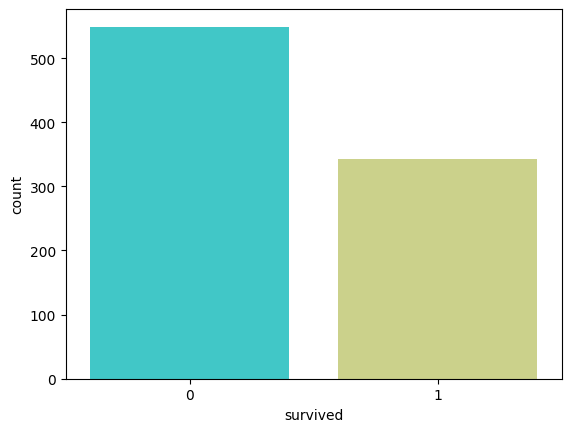

In [ ]:
sns.countplot(x='survived',data=train,palette='rainbow')

<Axes: ylabel='count'>

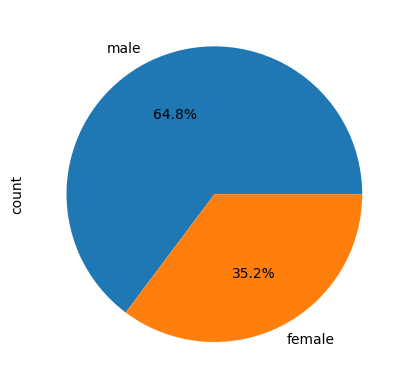

In [ ]:
train['sex'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: xlabel='age', ylabel='Count'>

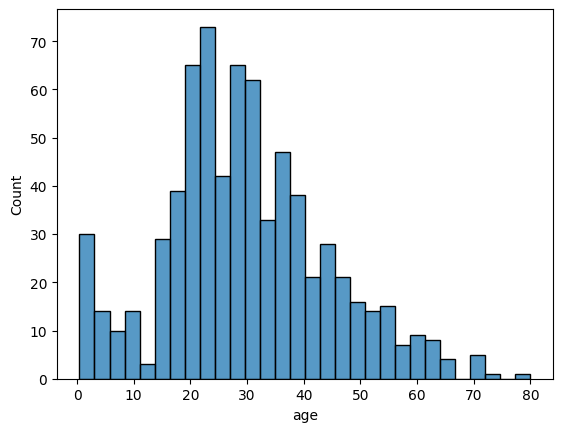

In [ ]:
sns.histplot(train['age'],bins=30)

<Axes: xlabel='fare', ylabel='Count'>

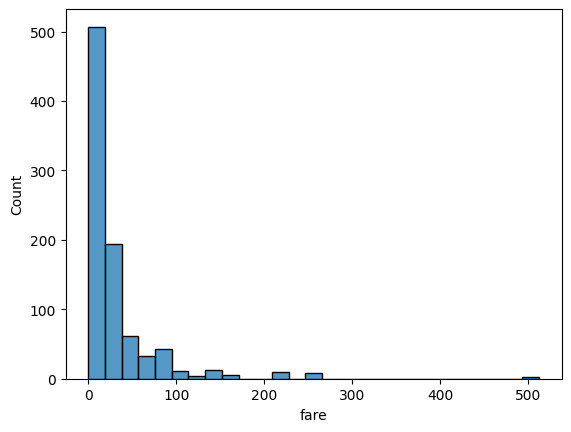

In [ ]:
sns.histplot(train['fare'],bins=27)

<Axes: xlabel='parch', ylabel='Count'>

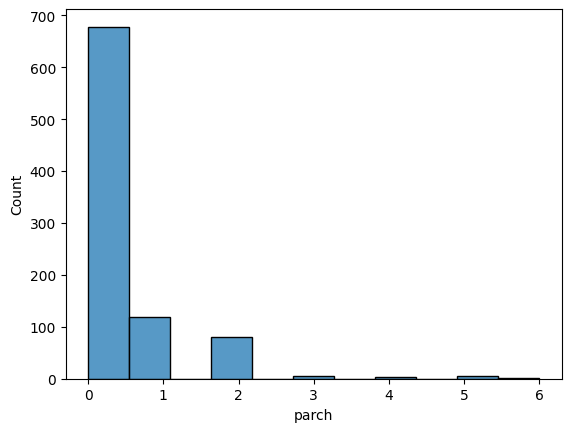

In [ ]:
sns.histplot(train['parch'])

<Axes: ylabel='age'>

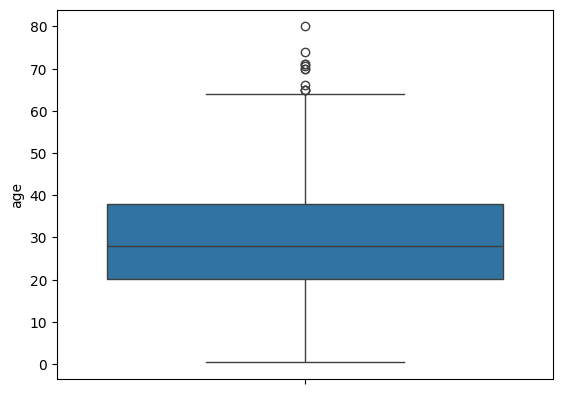

In [ ]:
sns.boxplot(train['age'])

##Bivariate Analysis
*   Categorical vs Categorical Features (Contingency Table etc.)
*   Categorical vs Numerical Features (Box Plot, Histogram etc)
*   Numerical vs Numerical Features (Scatter Plot etc)

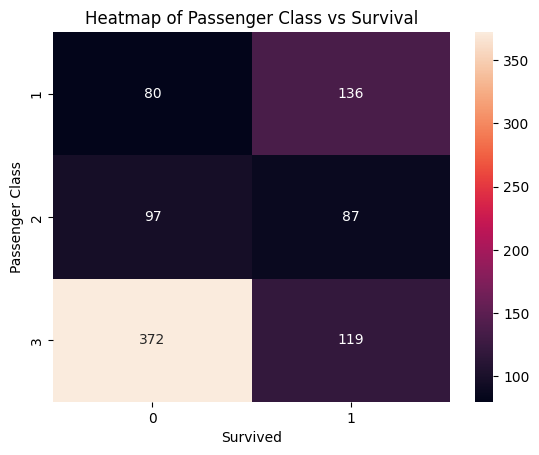

In [ ]:
import matplotlib.pyplot as plt
# Create a contingency table (cross-tabulation) for Pclass and Survived
ct=pd.crosstab(train['pclass'], train['survived'])

# Plot the heatmap
#plt.figure(figsize=(8, 6))
sns.heatmap(ct,annot=True,fmt='d')
plt.title('Heatmap of Passenger Class vs Survival')
plt.xlabel('Survived')
plt.ylabel('Passenger Class')
plt.show()

<Axes: xlabel='survived', ylabel='count'>

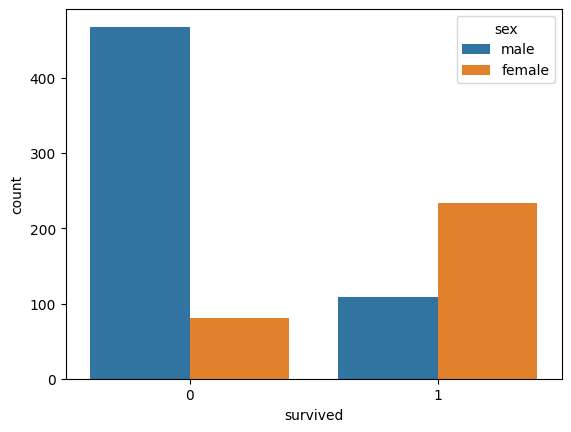

In [ ]:
sns.countplot(x='survived',hue='sex',data=train)

<Axes: xlabel='survived', ylabel='count'>

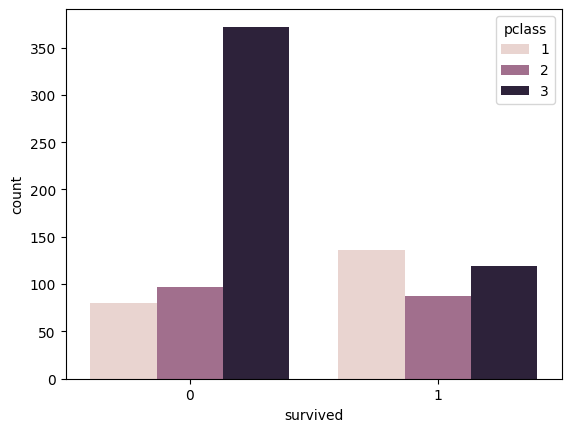

In [ ]:
sns.countplot(x='survived',hue='pclass',data=train)

<Axes: xlabel='pclass', ylabel='age'>

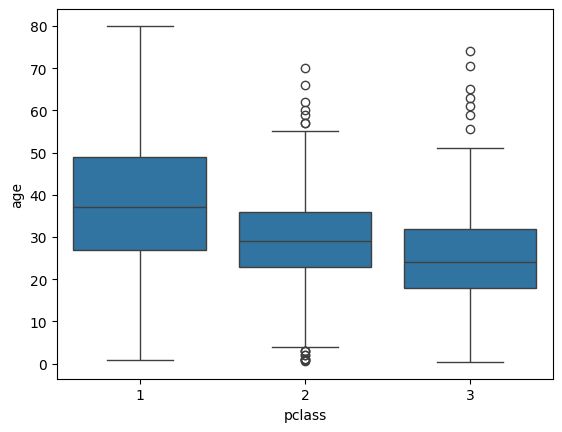

In [ ]:
sns.boxplot(x='pclass', y='age', data=train)

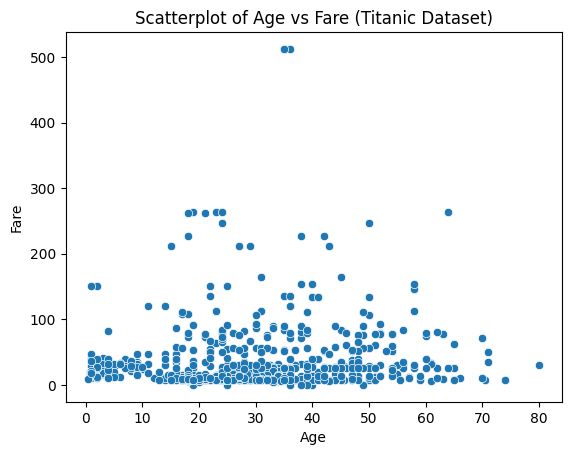

In [ ]:
# Create a scatterplot for Age vs Fare
#plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='fare', data=train)

# Add titles and alabels
plt.title('Scatterplot of Age vs Fare (Titanic Dataset)')
plt.xlabel('Age')
plt.ylabel('Fare')

# Show the plot
plt.show()

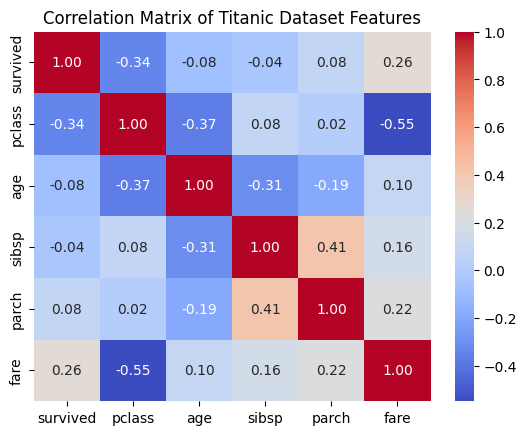

In [ ]:
# Select only numerical columns for correlation analysis
numerical_features = train.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
correlation_matrix = numerical_features.corr()

# Set up the matplotlib figure
#plt.figure(figsize=(10, 8))

# Generate a heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')

# Add titles and labels
plt.title('Correlation Matrix of Titanic Dataset Features')
plt.show()


##Multivariate Analysis

<Axes: xlabel='age', ylabel='fare'>

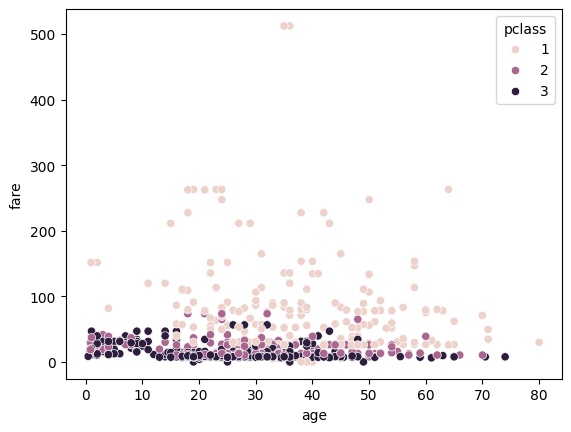

In [ ]:
sns.scatterplot(x='age', y='fare', hue='pclass', data=train)

# **Pandas_Profiling**

# New Section

In [ ]:
## Pandas Profiling

!pip install ydata-profiling # Install Library

import pandas as pd
from ydata_profiling import ProfileReport # Import Library


# Load the Titanic dataset
df=pd.read_csv('/content/Titanic.csv')

# Generate the profiling report
prof = ProfileReport(df)
prof.to_file(output_file='eda.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 43.77it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

##Data Preparation

*   Data Imputation
*   Feature Encoding
*   Identifying duplicated columns
*   Dropping irrelevant columns and rows
*   Renaming Columns

## Data Imputation
We want to fill in missing age data instead of just dropping the missing age data rows. One way to do this is by filling in the mean age of all the passengers (imputation).
However we can be smarter about this and check the average age by passenger class. For example:

In [ ]:
train.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
train.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

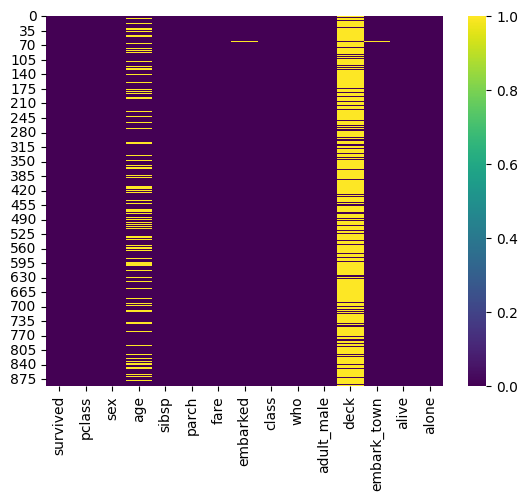

In [ ]:
sns.heatmap(train.isnull(),cmap='viridis')

In [ ]:
mean_values = train.groupby('pclass')['age'].mean()
print(mean_values)

pclass
1    38.233441
2    29.877630
3    25.140620
Name: age, dtype: float64


We can see the wealthier passengers in the higher classes tend to be older, which makes sense. We'll use these average age values to impute based on Pclass for Age.

In [ ]:
def impute_age(cols):
    age = cols[0]
    pclass = cols[1]

    if pd.isnull(age):

        if pclass == 1:
            return 37

        elif pclass == 2:
            return 29

        else:
            return 24

    else:
        return age

Now apply that function!

In [ ]:
train['age'] = train[['age','pclass']].apply(impute_age, axis=1)

/tmp/ipykernel_5416/2128663108.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age = cols[0]
/tmp/ipykernel_5416/2128663108.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pclass = cols[1]


Now let's check that heat map again!

<Axes: >

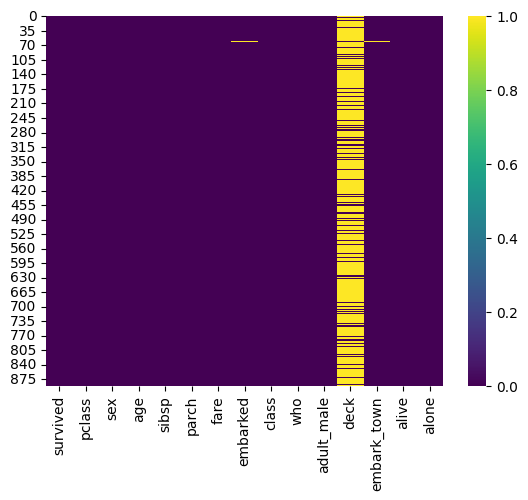

In [ ]:
sns.heatmap(train.isnull(),cmap='viridis')

**Identifying Duplicated Columns**

In [ ]:
train.loc[train.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,24.0,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,24.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,24.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,24.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
89,0,3,male,24.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,24.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
train.drop(['Embarked','Name','Ticket','Cabin'],axis=1,inplace=True)

In [ ]:
train.shape

In [ ]:
train.columns

In [ ]:
train.head()

##Feature Encoding

In [ ]:
train.info()

In [ ]:
sex = pd.get_dummies(train['Sex'])

In [ ]:
train.head()

In [ ]:
train = pd.concat([train,sex],axis=1)

In [ ]:
train.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
train.drop(['sex'],axis=1,inplace=True)

In [ ]:
train.head()

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
train = train.rename(columns={'female':'Female','male':'Male'})

In [ ]:
train.head()

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   age          891 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  deck         203 non-null    category
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(4)
memory usage: 73.7+ KB


# Lab Task

Perform the steps mentioned above on the following dataset.

https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease

# **importing librarues**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as plt

## **data understanding**





reading data

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease")

print("Path to dataset files:", path)


100%|██████████| 21.4M/21.4M [00:02<00:00, 8.72MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/versions/6


In [4]:
train = pd.read_csv('/content/heart_2020_cleaned.csv')

In [5]:
train.shape


(319795, 18)

In [6]:
train.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [7]:
train.tail()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No
319794,No,46.56,No,No,No,0.0,0.0,No,Female,80 or older,Hispanic,No,Yes,Good,8.0,No,No,No


In [8]:
train.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [9]:
train.dtypes

,0
HeartDisease,object
BMI,float64
Smoking,object
AlcoholDrinking,object
Stroke,object
PhysicalHealth,float64
MentalHealth,float64
DiffWalking,object
Sex,object
AgeCategory,object


unique values

In [10]:
train.nunique()

,0
HeartDisease,2
BMI,3604
Smoking,2
AlcoholDrinking,2
Stroke,2
PhysicalHealth,31
MentalHealth,31
DiffWalking,2
Sex,2
AgeCategory,13


In [11]:
train['Sex'].unique()

array(['Female', 'Male'], dtype=object)

<Axes: xlabel='Smoking'>

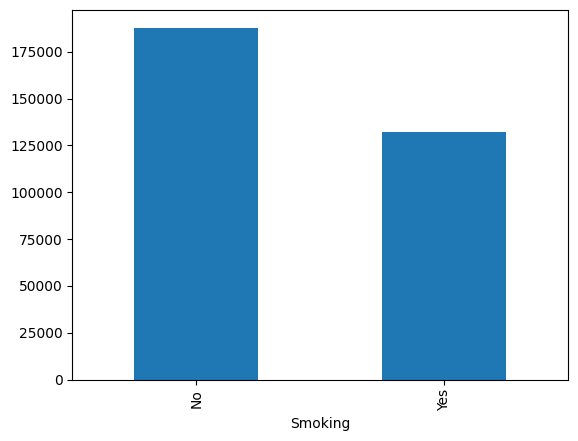

In [15]:
train['Smoking'].value_counts().plot(kind='bar')



/tmp/ipykernel_4075/1717938548.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease',data=train,palette='rainbow')


<Axes: xlabel='HeartDisease', ylabel='count'>

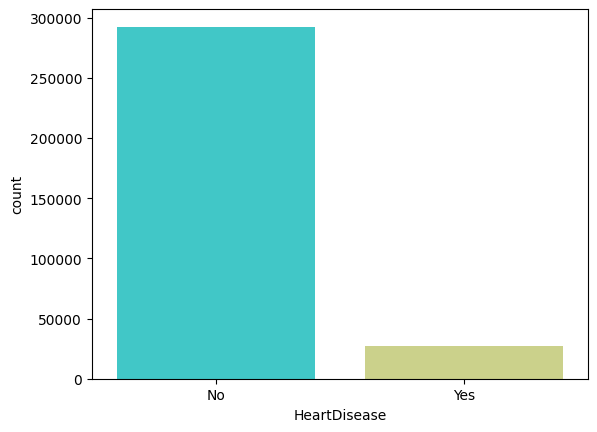

In [16]:
sns.countplot(x='HeartDisease',data=train,palette='rainbow')

<Axes: ylabel='count'>

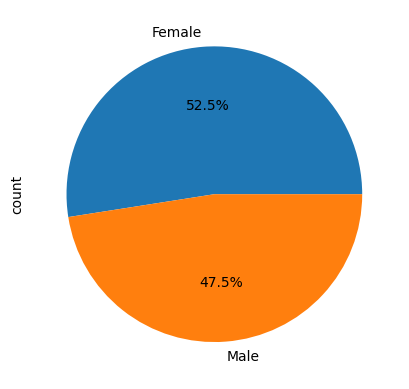

In [17]:
train['Sex'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

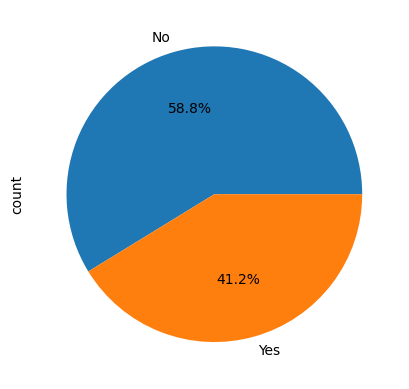

In [18]:
train['Smoking'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: xlabel='BMI', ylabel='Count'>

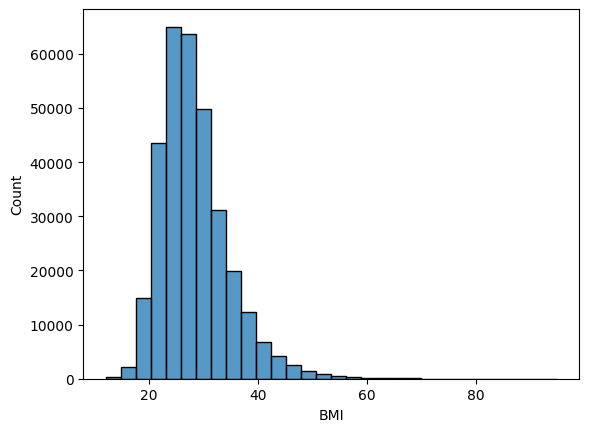

In [19]:
sns.histplot(train['BMI'],bins=30)

<Axes: xlabel='PhysicalHealth', ylabel='Count'>

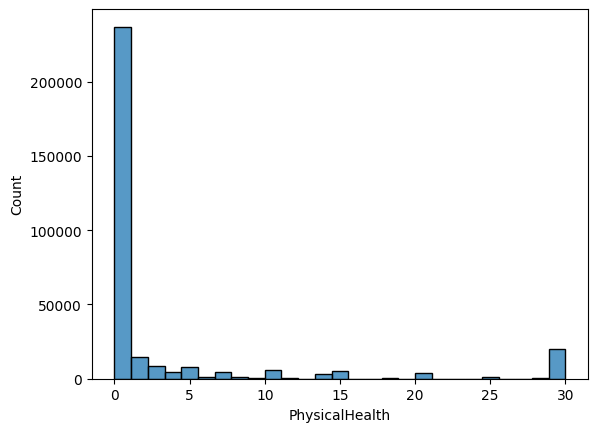

In [ ]:
sns.histplot(train['PhysicalHealth'],bins=27)

<Axes: xlabel='MentalHealth', ylabel='Count'>

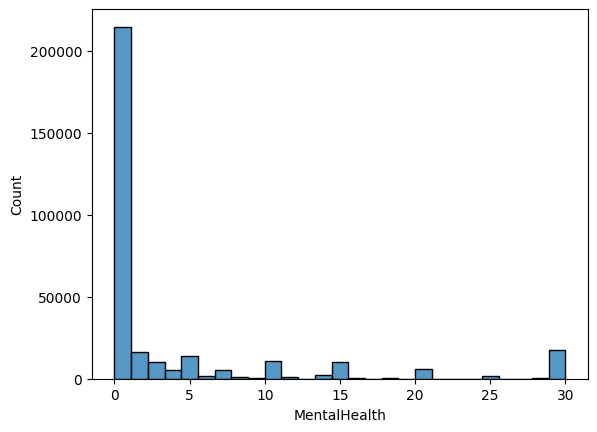

In [20]:
sns.histplot(train['MentalHealth'],bins=27)

# **Bivariate Analysis**
* Categorical vs Categorical Features (Contingency Table etc.)

* Categorical vs Numerical Features (Box Plot, Histogram etc)
* Numerical vs Numerical Features (Scatter Plot etc)

Categorical vs Categorical

In [22]:
pd.crosstab(train['HeartDisease'], train['Smoking'])

Smoking,No,Yes
HeartDisease,,
No,176551,115871
Yes,11336,16037


<Axes: xlabel='Smoking', ylabel='count'>

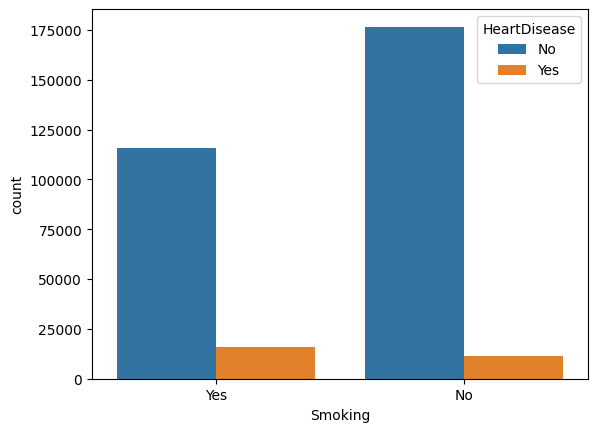

In [24]:
sns.countplot(x='Smoking', hue='HeartDisease', data=train)



**Boxplot (Categorical vs Numerical)**

<Axes: xlabel='HeartDisease', ylabel='BMI'>

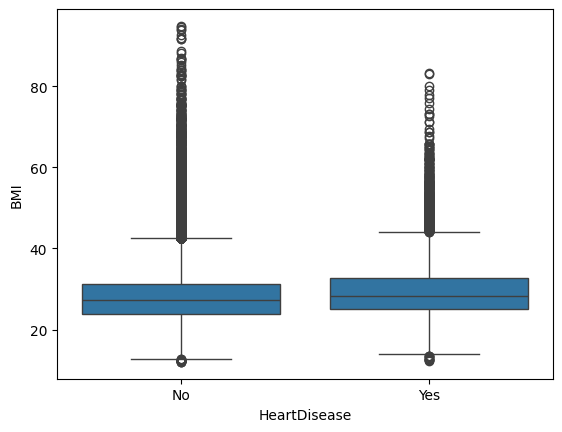

In [25]:
sns.boxplot(x='HeartDisease', y='BMI', data=train)


**Scatterplot (Numerical vs Numerical)**

<Axes: xlabel='BMI', ylabel='SleepTime'>

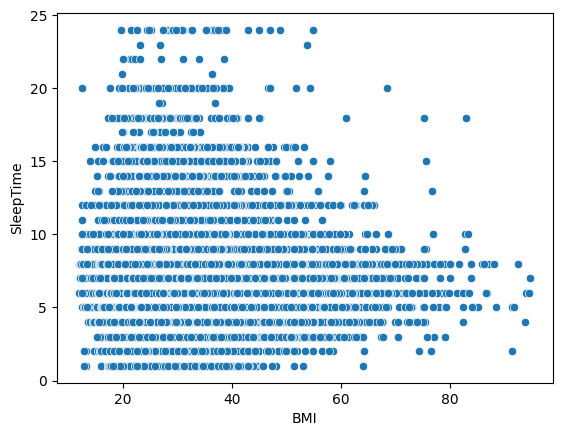

In [26]:
sns.scatterplot(x='BMI', y='SleepTime', data=train)


**Histogram of Numerical Feature**

<Axes: xlabel='MentalHealth', ylabel='Count'>

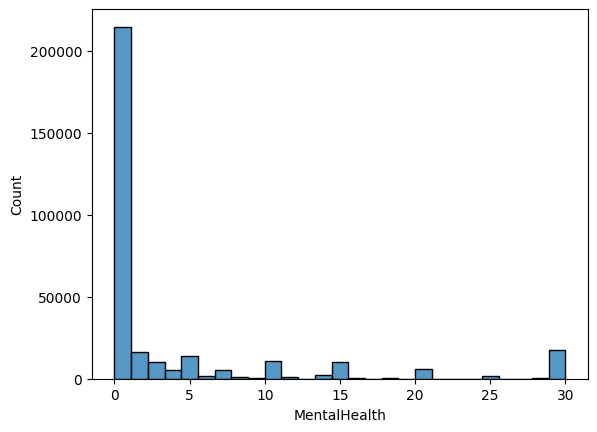

In [27]:
sns.histplot(train['MentalHealth'], bins=27)


# **Pandas_Profiling**

Check for Missing Values

In [28]:
train.isnull().sum()

,0
HeartDisease,0
BMI,0
Smoking,0
AlcoholDrinking,0
Stroke,0
PhysicalHealth,0
MentalHealth,0
DiffWalking,0
Sex,0
AgeCategory,0


Drop Rows With Missing Values (if necessary)

In [29]:

train.dropna(subset=['BMI', 'HeartDisease'], inplace=True)

In [30]:
train

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


**Feature Encoding (Convert Categorical to Numeric)**

**Label Encoding (Yes/No → 0/1)**

In [31]:
train['HeartDisease'] = train['HeartDisease'].map({'Yes':1, 'No':0})
train['Smoking'] = train['Smoking'].map({'Yes':1, 'No':0})

**One-Hot Encoding (Multiple Categories)**

In [32]:
train = pd.get_dummies(train, columns=['Race', 'AgeCategory'], drop_first=True)

In [33]:
train

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,Diabetic,...,AgeCategory_35-39,AgeCategory_40-44,AgeCategory_45-49,AgeCategory_50-54,AgeCategory_55-59,AgeCategory_60-64,AgeCategory_65-69,AgeCategory_70-74,AgeCategory_75-79,AgeCategory_80 or older
0,0,16.60,1,No,No,3.0,30.0,No,Female,Yes,...,False,False,False,False,True,False,False,False,False,False
1,0,20.34,0,No,Yes,0.0,0.0,No,Female,No,...,False,False,False,False,False,False,False,False,False,True
2,0,26.58,1,No,No,20.0,30.0,No,Male,Yes,...,False,False,False,False,False,False,True,False,False,False
3,0,24.21,0,No,No,0.0,0.0,No,Female,No,...,False,False,False,False,False,False,False,False,True,False
4,0,23.71,0,No,No,28.0,0.0,Yes,Female,No,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,1,27.41,1,No,No,7.0,0.0,Yes,Male,Yes,...,False,False,False,False,False,True,False,False,False,False
319791,0,29.84,1,No,No,0.0,0.0,No,Male,No,...,True,False,False,False,False,False,False,False,False,False
319792,0,24.24,0,No,No,0.0,0.0,No,Female,No,...,False,False,True,False,False,False,False,False,False,False
319793,0,32.81,0,No,No,0.0,0.0,No,Female,No,...,False,False,False,False,False,False,False,False,False,False


**Identifying Duplicated Columns**

In [36]:
duplicated_cols = train.columns[train.columns.duplicated()]
print(duplicated_cols)

Index([], dtype='object')


**Remove duplicates if found**

In [37]:
train = train.loc[:, ~train.columns.duplicated()]

**Dropping Irrelevant Columns or Rows**

In [40]:
if 'SkinCancer' in train.columns:
    train.drop(columns=['SkinCancer'], inplace=True)

In [41]:
train.drop(columns=['SkinCancer'], errors='ignore', inplace=True)

In [42]:
train.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'Diabetic',
       'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease',
       'Race_Asian', 'Race_Black', 'Race_Hispanic', 'Race_Other', 'Race_White',
       'AgeCategory_25-29', 'AgeCategory_30-34', 'AgeCategory_35-39',
       'AgeCategory_40-44', 'AgeCategory_45-49', 'AgeCategory_50-54',
       'AgeCategory_55-59', 'AgeCategory_60-64', 'AgeCategory_65-69',
       'AgeCategory_70-74', 'AgeCategory_75-79', 'AgeCategory_80 or older'],
      dtype='object')

**Renaming Columns**

In [43]:
train.rename(columns={
    'PhysicalHealth':'PhysHealth',
    'MentalHealth':'MentHealth',
    'AlcoholDrinking':'Alcohol',
    'DiffWalking':'DiffWalk'
}, inplace=True)

In [44]:
train.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'Alcohol', 'Stroke', 'PhysHealth',
       'MentHealth', 'DiffWalk', 'Sex', 'Diabetic', 'PhysicalActivity',
       'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'Race_Asian',
       'Race_Black', 'Race_Hispanic', 'Race_Other', 'Race_White',
       'AgeCategory_25-29', 'AgeCategory_30-34', 'AgeCategory_35-39',
       'AgeCategory_40-44', 'AgeCategory_45-49', 'AgeCategory_50-54',
       'AgeCategory_55-59', 'AgeCategory_60-64', 'AgeCategory_65-69',
       'AgeCategory_70-74', 'AgeCategory_75-79', 'AgeCategory_80 or older'],
      dtype='object')